In [1]:
!pip install lmdb

In [1]:
# =========================
# Fast CRNN-CTC Training (compile OFF, CNN=AMP, LSTM=FP32, faster it/s)
# =========================
import os, re, six, math, lmdb, time
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from IPython.display import display

# ---- Device & Backend Tweaks ----
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# TF32 허용 (Ampere 이상에서 matmul/conv 가속)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# cudnn autotune
torch.backends.cudnn.benchmark = True
try:
    torch.set_float32_matmul_precision('high')
except Exception:
    pass

Using device: cuda


In [2]:
# =========================
# Paths & Characters
# =========================
data_dir = os.path.join(os.getenv("HOME"), "work/ocr/data")
os.chdir(data_dir)
print(data_dir)

NUMBERS = "0123456789"
ENG_CHAR_UPPER = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
TARGET_CHARACTERS = ENG_CHAR_UPPER + NUMBERS
print(f"The total number of characters is {len(TARGET_CHARACTERS)}")

TRAIN_DATA_PATH = data_dir + '/MJ/MJ_train'
VALID_DATA_PATH = data_dir + '/MJ/MJ_valid'
TEST_DATA_PATH  = data_dir + '/MJ/MJ_test'
print(TRAIN_DATA_PATH)

/home/jovyan/work/ocr/data
The total number of characters is 36
/home/jovyan/work/ocr/data/MJ/MJ_train


original image width:72, height:31
target_img_size:(74, 32)
display img shape:(74, 32, 3)
label:Lube


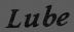

original image width:82, height:31
target_img_size:(84, 32)
display img shape:(84, 32, 3)
label:Spencerian


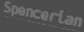

original image width:115, height:31
target_img_size:(100, 32)
display img shape:(100, 32, 3)
label:accommodatingly


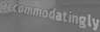

original image width:140, height:31
target_img_size:(100, 32)
display img shape:(100, 32, 3)
label:CARPENTER


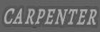

In [3]:
# =========================
# Quick LMDB glance
# =========================
env = lmdb.open(TRAIN_DATA_PATH,
                max_readers=32,
                readonly=True,
                lock=False,
                readahead=False,
                meminit=False)

with env.begin(write=False) as txn:
    for index in range(1, 5):
        label_key = 'label-%09d'.encode() % index
        label = txn.get(label_key).decode('utf-8')
        img_key = 'image-%09d'.encode() % index
        imgbuf = txn.get(img_key)
        buf = six.BytesIO(); buf.write(imgbuf); buf.seek(0)

        try:
            img = Image.open(buf).convert('RGB')
        except IOError:
            img = Image.new('RGB', (100, 32))
            label = '-'

        width, height = img.size
        print('original image width:{}, height:{}'.format(width, height))
        target_width = min(int(width*32/height), 100)
        target_img_size = (target_width, 32)
        print('target_img_size:{}'.format(target_img_size))

        img_np = np.array(img.resize(target_img_size)).transpose(1,0,2)
        print('display img shape:{}'.format(img_np.shape))
        print('label:{}'.format(label))
        display(Image.fromarray(img_np.transpose(1,0,2).astype(np.uint8)))

In [4]:
# =========================
# Label Converter
# =========================
class LabelConverter(object):
    def __init__(self, character):
        self.character = "-" + character   # 0 = CTC blank
        self.label_map = {ch:i for i, ch in enumerate(self.character)}

    def encode(self, text):
        text = text.upper()
        encoded_label = []
        for i, ch in enumerate(text):
            if i > 0 and ch == text[i - 1]:
                encoded_label.append(0)    # blank between double chars
            encoded_label.append(self.label_map.get(ch, 0))
        return np.array(encoded_label, dtype=np.int32)

    def decode(self, encoded_label):
        return "".join(self.character[idx] for idx in encoded_label)

label_converter = LabelConverter(TARGET_CHARACTERS)
encdoded_text = label_converter.encode('HELLO')
print("Encdoded_text: ", encdoded_text)
decoded_text = label_converter.decode(encdoded_text)
print("Decoded_text: ", decoded_text)

Encdoded_text:  [ 8  5 12  0 12 15]
Decoded_text:  HEL-LO


In [5]:
# =========================
# Dataset
# =========================
class MJDataset(Dataset):
    def __init__(self, dataset_path, label_converter, img_size=(100, 32), max_text_len=22, character=""):
        super().__init__()
        self.label_converter = label_converter
        self.img_size = img_size      # (W, H)
        self.max_text_len = max_text_len
        self.character = character

        self.env = lmdb.open(dataset_path, max_readers=32, readonly=True, lock=False, readahead=False, meminit=False)
        with self.env.begin(write=False) as txn:
            self.num_samples = int(txn.get("num-samples".encode()))
            self.index_list = [idx + 1 for idx in range(self.num_samples)]

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        index = self.index_list[idx]
        with self.env.begin(write=False) as txn:
            label_key = f"label-{index:09d}".encode()
            label = txn.get(label_key).decode("utf-8")
            img_key = f"image-{index:09d}".encode()
            imgbuf = txn.get(img_key)

            buf = six.BytesIO(); buf.write(imgbuf); buf.seek(0)
            try:
                img_pil = Image.open(buf).convert("RGB")
            except IOError:
                img_pil = Image.new("RGB", self.img_size)
                label = "-"

        orig_w, orig_h = img_pil.size
        target_width = min(int(orig_w * self.img_size[1] / orig_h), self.img_size[0])
        target_img_size = (target_width, self.img_size[1])  # (W, H)
        img_pil = img_pil.resize(target_img_size)

        img = np.array(img_pil, dtype=np.float32) / 255.0
        img = img.transpose(2, 0, 1)  # CHW
        padded_img = np.zeros((3, self.img_size[1], self.img_size[0]), dtype=np.float32)
        c, h, w = img.shape
        padded_img[:, :h, :w] = img
        img_t = torch.from_numpy(padded_img)  # float32, CHW

        label = label.upper()
        out_of_char = f"[^{self.character}]"
        label = re.sub(out_of_char, "", label)
        label = label[: self.max_text_len]
        encoded_label = self.label_converter.encode(label)

        return img_t, encoded_label, len(encoded_label), label

In [6]:
# =========================
# Collate (CTC용 / input_lengths는 학습 루프에서 생성)
# =========================
def collate_fn(batch):
    imgs, encoded_labels, label_lens, raw_labels = zip(*batch)
    imgs_tensor = torch.stack(imgs, dim=0)            # (B,3,H,W), float32
    max_len = max(label_lens)
    labels_padded = torch.zeros(len(batch), max_len, dtype=torch.long)
    for i, arr in enumerate(encoded_labels):
        L = label_lens[i]
        labels_padded[i, :L] = torch.tensor(arr, dtype=torch.long)
    label_length = torch.tensor(label_lens, dtype=torch.long)
    return imgs_tensor, labels_padded, label_length, raw_labels

In [7]:
# =========================
# Model
# =========================
class CRNN(nn.Module):
    def __init__(self, num_chars, img_height=32, img_width=100):
        super(CRNN, self).__init__()
        self.num_chars = num_chars

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d((1, 2))

        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.conv6 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(512)
        self.pool4 = nn.MaxPool2d((1, 2))

        self.conv7 = nn.Conv2d(512, 512, kernel_size=(2, 2))

        self.lstm1 = nn.LSTM(512, 256, bidirectional=True, batch_first=True)
        self.lstm2 = nn.LSTM(512, 256, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(512, self.num_chars)

    def forward(self, x):
        # CNN 부분 (autocast 이득 큼)
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool3(x)
        x = F.relu(self.conv5(x)); x = self.bn5(x)
        x = F.relu(self.conv6(x)); x = self.bn6(x)
        x = self.pool4(x)
        x = F.relu(self.conv7(x))

        b, c, h, w = x.size()
        x = x.view(b, c, h*w).permute(0, 2, 1)  # (B,T,512), T=h*w

        # LSTM은 FP32가 보통 더 빠르고 안정적
        x = x.float()
        x, _ = self.lstm1(x)           # (B,T,512)
        x, _ = self.lstm2(x)           # (B,T,512)
        x = self.fc(x)                 # (B,T,num_chars)
        x = x.permute(1, 0, 2)         # (T,B,num_chars)
        return x

In [8]:
# =========================
# Hyperparams & Dataloaders
# =========================
MAX_TEXT_LEN = 22
IMG_SIZE = (100, 32)   # (W,H)
BATCH_SIZE = 64        # 128 -> 64 로 낮춰 1 step 시간 단축

label_converter = LabelConverter(TARGET_CHARACTERS)
num_chars = len(label_converter.character)

train_dataset = MJDataset(TRAIN_DATA_PATH, label_converter=label_converter, img_size=IMG_SIZE, character=TARGET_CHARACTERS)
valid_dataset = MJDataset(VALID_DATA_PATH, label_converter=label_converter, img_size=IMG_SIZE, character=TARGET_CHARACTERS)
test_dataset  = MJDataset(TEST_DATA_PATH , label_converter=label_converter, img_size=IMG_SIZE, character=TARGET_CHARACTERS)

NUM_WORKERS = max((os.cpu_count() or 2)//2, 2)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    drop_last=False,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    drop_last=False,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    drop_last=False,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)

In [9]:
# =========================
# Model / Loss / Optimizer
# =========================
model = CRNN(num_chars=num_chars).to(device)
model = model.to(memory_format=torch.channels_last)  # CNN 가속

criterion = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-3,
    betas=(0.9, 0.999),
    weight_decay=0.01,
    fused=True if torch.cuda.is_available() else False
)

# ---- AMP (new API) : CNN에 효과, LSTM은 forward에서 FP32로 강제 ----
from torch.amp import autocast, GradScaler
scaler = GradScaler('cuda' if torch.cuda.is_available() else 'cpu')

In [10]:
# =========================
# Training Loop (with imgs/sec)
# =========================
def run_training(
        train_loader,
        valid_loader,
        model,
        optimizer,
        criterion,
        patience=2,
        epochs=1,
        checkpoint_path="~/work/ocr/model_checkpoint.pth",
        batch_limit=500,
        device=None
        ):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    best_val_loss = float('inf')
    patience_counter = 0
    checkpoint_path = os.path.expanduser(checkpoint_path)

    print("학습 시작!...")

    for epoch in range(1, epochs+1):
        # ---- Train ----
        model.train()
        train_loss_sum, train_steps = 0.0, 0
        train_max_steps = len(train_loader) if batch_limit is None else min(len(train_loader), batch_limit)
        pbar_train = tqdm(enumerate(train_loader), total=train_max_steps, desc=f"[Epoch {epoch}/{epochs}] Train", leave=False)

        for idx, (imgs, labels_padded, label_lengths, _) in pbar_train:
            if batch_limit is not None and idx >= batch_limit: break

            t0 = time.perf_counter()

            imgs = imgs.to(device, non_blocking=True).to(memory_format=torch.channels_last)
            labels_padded = labels_padded.to(device, non_blocking=True)
            label_lengths = label_lengths.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            # CNN 영역만 autocast 이득 (LSTM은 내부에서 FP32)
            with autocast('cuda', enabled=torch.cuda.is_available()):
                outputs = model(imgs)              # (T,B,C)
                log_probs = F.log_softmax(outputs, dim=2)
                T_, B_, C_ = log_probs.shape
                input_lengths = torch.full((B_,), T_, dtype=torch.long, device=device)
                loss = criterion(log_probs, labels_padded, input_lengths, label_lengths)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            dt = time.perf_counter() - t0
            imgs_per_sec = imgs.size(0) / max(dt, 1e-6)

            train_loss_sum += loss.item()
            train_steps += 1
            pbar_train.set_postfix(loss=f"{train_loss_sum/train_steps:.4f}",
                                   ips=f"{imgs_per_sec:,.1f} img/s")

        # ---- Valid ----
        model.eval()
        valid_loss_sum, valid_steps = 0.0, 0
        valid_max_steps = len(valid_loader) if batch_limit is None else min(len(valid_loader), batch_limit)
        pbar_valid = tqdm(enumerate(valid_loader), total=valid_max_steps, desc=f"[Epoch {epoch}/{epochs}] Valid", leave=False)

        with torch.no_grad():
            for idx, (imgs, labels_padded, label_lengths, _) in pbar_valid:
                if batch_limit is not None and idx >= batch_limit: break

                imgs = imgs.to(device, non_blocking=True).to(memory_format=torch.channels_last)
                labels_padded = labels_padded.to(device, non_blocking=True)
                label_lengths = label_lengths.to(device, non_blocking=True)

                with autocast('cuda', enabled=torch.cuda.is_available()):
                    outputs = model(imgs)
                    log_probs = F.log_softmax(outputs, dim=2)
                    T_, B_, C_ = log_probs.shape
                    input_lengths = torch.full((B_,), T_, dtype=torch.long, device=device)
                    loss = criterion(log_probs, labels_padded, input_lengths, label_lengths)

                valid_loss_sum += loss.item()
                valid_steps += 1
                pbar_valid.set_postfix(loss=f"{valid_loss_sum/valid_steps:.4f}")

        avg_train_loss = train_loss_sum / max(1, train_steps)
        avg_valid_loss = valid_loss_sum / max(1, valid_steps)
        print(f"[Epoch {epoch}/{epochs}] train_loss={avg_train_loss:.4f}, val_loss={avg_valid_loss:.4f}")

        # checkpoint & early stopping
        if avg_valid_loss < best_val_loss:
            best_val_loss = avg_valid_loss
            patience_counter = 0
            os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Model improved. Saved at {checkpoint_path}")
        else:
            patience_counter += 1
            print(f"No improvement. patience {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    return model

In [11]:
# =========================
# Kick Training
# =========================
model = run_training(train_loader, valid_loader, model, optimizer, criterion,
                     patience=2, epochs=5, checkpoint_path="~/work/ocr/model_checkpoint.pth",
                     batch_limit=500, device=device)


학습 시작!...


[Epoch 1/5] Train:   0%|          | 0/500 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [13]:
# 다음은 학습된 모델의 가중치가 저장된 경로입니다
checkpoint_path = "/home/jovyan/work/ocr/model_checkpoint.pth"

# 데이터셋과 모델을 불러옵니다
IMG_SIZE = (100, 32)
BATCH_SIZE = 128

test_dataset = MJDataset(TEST_DATA_PATH,label_converter=label_converter,img_size=IMG_SIZE,character=TARGET_CHARACTERS)
test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=2,collate_fn=collate_fn,drop_last=False)

label_converter = LabelConverter(TARGET_CHARACTERS)
num_chars = len(label_converter.character)
print(num_chars)

model = CRNN(num_chars=num_chars).to(device)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

37


CRNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv6): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn6): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): MaxPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0, dilation=

In [14]:
def decode_greedy(output, label_converter):
    # (T,B,C) -> (B,T) index
    out = output.detach().cpu().numpy()  # (T,B,C)
    argmax = out.argmax(axis=2).transpose()  # (B,T)

    results = []
    for seq in argmax:
        # 연속된 동일 글자(또는 blank=0) 제거 로직을 적용해야
        # CTC 디코딩다운 결과가 나옵니다.
        # 여기서는 간단히 blank(0) 무시하고 연속 제거만 보여줌
        decoded = []
        prev = None
        for idx in seq:
            if idx != 0 and idx != prev:
                decoded.append(idx)
            prev = idx
        # 인덱스를 실제 문자로
        decoded_str = label_converter.decode(decoded).replace('-', '')
        results.append(decoded_str)
    return results

In [19]:
def check_inference(model, dataset, index=5):
    for i in range(index):
        img, encoded_label, label_len, raw_label = dataset[i]  # 단일 데이터
        img_tensor = img.unsqueeze(0).float().to(device)  # (1,3,32,100) ← torch.tensor() 경고 제거
        output = model(img_tensor)

        # 디코딩
        result_text = decode_greedy(output, label_converter)[0]
        print(f"GT: {raw_label} / Pred: {result_text}")

        # 시각화
        img_np = img.permute(1, 2, 0).cpu().numpy()
        if img_np.max() <= 1.0:  # 0~1
            img_np = (img_np * 255).astype(np.uint8)
        elif img_np.min() < 0:  # -1~1
            img_np = ((img_np + 1) * 127.5).astype(np.uint8)
        else:
            img_np = img_np.astype(np.uint8)

        display(Image.fromarray(img_np))


GT: SLINKING / Pred: STIING


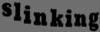

GT: REMODELERS / Pred: MUNTE


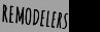

GT: CHRONOGRAPHS / Pred: UNTS


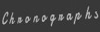

GT: IMPEACHING / Pred: MUNTING


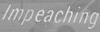

GT: DISCOMBOBULATED / Pred: MANLN


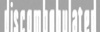

GT: LOOTS / Pred: LOS


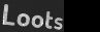

GT: UNDERPAYS / Pred: ONRTS


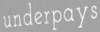

GT: FLAMEPROOFED / Pred: CLANNS


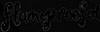

GT: ENTICEMENTS / Pred: UNESERS


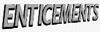

GT: UKASE / Pred: WIS


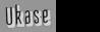

In [20]:
check_inference(model, test_dataset, index=10)

# 프로젝트: End-to-End OCR

In [25]:
!pip install opencv-python
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 MB 77.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.8/963.8 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [easyocr]m5/6 [easyocr]ython-headless]


In [26]:
import os
import numpy as np
from PIL import Image, ImageDraw
import cv2

print("NumPy:", np.__version__)
print("PIL:", Image.__version__)
print("OpenCV:", cv2.__version__)

NumPy: 2.2.6
PIL: 11.2.1
OpenCV: 4.12.0


In [42]:
import easyocr

print("EasyOCR:", easyocr.__version__)

# EasyOCR Reader 생성 (필요한 언어 설정, 예: 영어)
reader = easyocr.Reader(['en'])

SAMPLE_IMG_PATH = 'ocr/data/sample.jpg'

EasyOCR: 1.7.2


In [43]:
def detect_text(img_path):
    # PIL로 이미지 열기
    img_pil = Image.open(img_path).convert('RGB')
    # EasyOCR은 numpy 배열을 입력받으므로 변환
    img_np = np.array(img_pil)

    # EasyOCR을 이용한 텍스트 검출 및 인식
    # 결과 형식: [(bbox, text, confidence), ...]
    ocr_result = reader.readtext(img_np)

    # 시각화를 위해 ImageDraw 객체 생성
    img_draw = ImageDraw.Draw(img_pil)
    cropped_imgs = []

    for bbox, text, conf in ocr_result:
        # 좌표를 정수형으로 변환
        bbox_int = [(int(x), int(y)) for x, y in bbox]
        img_draw.polygon(bbox_int, outline='red')

        xs = [pt[0] for pt in bbox_int]
        ys = [pt[1] for pt in bbox_int]
        x_min = max(0, min(xs) - 5)
        y_min = max(0, min(ys) - 5)
        x_max = max(xs) + 5
        y_max = max(ys) + 5
        word_box = (x_min, y_min, x_max, y_max)
        cropped_imgs.append(img_pil.crop(word_box))

    return img_pil, cropped_imgs, ocr_result

In [44]:
img_pil, cropped_imgs, ocr_result = detect_text(SAMPLE_IMG_PATH)
img_pil

FileNotFoundError: [Errno 2] No such file or directory: 'ocr/data/sample.jpg'

In [ ]:
def recognize_img(pil_img, input_img_size=(100, 32)):
    # TODO: 잘려진 단어 이미지를 인식하는 코드를 작성하세요!

    # PIL 이미지를 numpy 배열로 변환
    img_np = np.array(pil_img)
    # 인식 모델 입력 크기에 맞게 이미지 크기 조정
    img_resized = cv2.resize(img_np, input_img_size)

    # detail=0 옵션은 인식 결과의 텍스트만 반환합니다.
    result = reader.readtext(img_resized, detail=0, paragraph=False)

    if result:
        recognized_text = result[0]
    else:
        recognized_text = ""

    print("Recognized text:", recognized_text)
    return recognized_text

In [ ]:
for idx, word_img in enumerate(cropped_imgs):
    print(f"[{idx}] ", end="")
    recognize_img(word_img)